# 4. Test and Results

**Goal:** evaluate every saved model on the same train / validation / test data, compare them, and select the final model.

- Accuracies here are measured **without augmentation or dropout**, so train accuracy is comparable to val/test.
- The best model is **selected by validation accuracy**; test accuracy is the final unbiased score.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2})
TRAIN_C, VAL_C, TEST_C = '#2a78d6', '#eb6834', '#1baf7a'

data = np.load('data/dataset.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

Train: (5120, 224, 224, 3) | Val: (1097, 224, 224, 3) | Test: (1098, 224, 224, 3)


## 4.1 Model List

In [2]:
simple_df = pd.read_csv('results/simple_cnn_results.csv').assign(Type='Simple CNN')
pretrained_df = pd.read_csv('results/pretrained_results.csv').assign(Type='Pretrained')
info = pd.concat([simple_df, pretrained_df], ignore_index=True)
info[['Model', 'Type', 'Architecture', 'Layers', 'Params', 'Trainable Params', 'Epochs Run', 'Best Epoch', 'Train Time (s)']]

,Model,Type,Architecture,Layers,Params,Trainable Params,Epochs Run,Best Epoch,Train Time (s)
0,CNN_1,Simple CNN,"Conv [32, 64]",22,25719945,25719497,20,15,1390
1,CNN_2,Simple CNN,"Conv [32, 64, 64]",27,6489545,6488969,20,15,2584
2,CNN_3,Simple CNN,"Conv [32, 64, 128]",27,12949257,12948553,23,18,1956
3,CNN_4,Simple CNN,"Conv [32, 64, 128, 128]",32,3463561,3462601,21,16,1877
4,MobileNetV2,Pretrained,MobileNetV2 (frozen) + Dense 256,165,2604681,346697,19,14,553
5,ResNet50V2,Pretrained,ResNet50V2 (frozen) + Dense 256,201,24108105,543305,16,11,1430
6,EfficientNetB0,Pretrained,EfficientNetB0 (frozen) + Dense 256,248,4396268,346697,11,6,480


## 4.2 Evaluate All Models

In [3]:
rows = []
for _, r in info.iterrows():
    model = keras.models.load_model(f"models/{r['Model']}.keras")
    acc = lambda X, y: model.evaluate(X, y, batch_size=64, verbose=0)[1]
    rows.append({'Model': r['Model'], 'Type': r['Type'], 'Architecture': r['Architecture'],
                 'Layers': r['Layers'], 'Params': r['Params'],
                 'Train Acc': acc(X_train, y_train), 'Val Acc': acc(X_val, y_val),
                 'Test Acc': acc(X_test, y_test), 'Train Time (s)': r['Train Time (s)']})
    print(rows[-1]['Model'], 'done')

res = pd.DataFrame(rows).round(4)
res['Gap (Train-Test)'] = (res['Train Acc'] - res['Test Acc']).round(4)
res.to_csv('results/all_results.csv', index=False)

CNN_1 done
CNN_2 done
CNN_3 done
CNN_4 done
MobileNetV2 done
ResNet50V2 done
EfficientNetB0 done


## 4.3 Simple CNN Models

In [4]:
res[res['Type'] == 'Simple CNN'].drop(columns='Type').reset_index(drop=True)

,Model,Architecture,Layers,Params,Train Acc,Val Acc,Test Acc,Train Time (s),Gap (Train-Test)
0,CNN_1,"Conv [32, 64]",22,25719945,0.7305,0.5998,0.6120,1390,0.1185
1,CNN_2,"Conv [32, 64, 64]",27,6489545,0.7619,0.6299,0.6302,2584,0.1317
2,CNN_3,"Conv [32, 64, 128]",27,12949257,0.7537,0.6308,0.6293,1956,0.1244
3,CNN_4,"Conv [32, 64, 128, 128]",32,3463561,0.8006,0.6645,0.6812,1877,0.1194


## 4.4 Pretrained Models

In [5]:
res[res['Type'] == 'Pretrained'].drop(columns='Type').reset_index(drop=True)

,Model,Architecture,Layers,Params,Train Acc,Val Acc,Test Acc,Train Time (s),Gap (Train-Test)
0,MobileNetV2,MobileNetV2 (frozen) + Dense 256,165,2604681,0.9824,0.8833,0.8980,553,0.0844
1,ResNet50V2,ResNet50V2 (frozen) + Dense 256,201,24108105,0.9842,0.8924,0.9035,1430,0.0807
2,EfficientNetB0,EfficientNetB0 (frozen) + Dense 256,248,4396268,0.9871,0.9152,0.9235,480,0.0636


## 4.5 All Models (sorted by validation accuracy)

In [6]:
all_sorted = res.sort_values('Val Acc', ascending=False).reset_index(drop=True)
best_name = all_sorted.loc[0, 'Model']
print('Best model:', best_name)
all_sorted.style.highlight_max(subset=['Train Acc', 'Val Acc', 'Test Acc'], color='#cfe3f7') \
                .format({'Params': '{:,}'}, precision=4)

Best model: EfficientNetB0


,Model,Type,Architecture,Layers,Params,Train Acc,Val Acc,Test Acc,Train Time (s),Gap (Train-Test)
0,EfficientNetB0,Pretrained,EfficientNetB0 (frozen) + Dense 256,248,"4,396,268",0.9871,0.9152,0.9235,480,0.0636
1,ResNet50V2,Pretrained,ResNet50V2 (frozen) + Dense 256,201,"24,108,105",0.9842,0.8924,0.9035,1430,0.0807
2,MobileNetV2,Pretrained,MobileNetV2 (frozen) + Dense 256,165,"2,604,681",0.9824,0.8833,0.8980,553,0.0844
3,CNN_4,Simple CNN,"Conv [32, 64, 128, 128]",32,"3,463,561",0.8006,0.6645,0.6812,1877,0.1194
4,CNN_3,Simple CNN,"Conv [32, 64, 128]",27,"12,949,257",0.7537,0.6308,0.6293,1956,0.1244
5,CNN_2,Simple CNN,"Conv [32, 64, 64]",27,"6,489,545",0.7619,0.6299,0.6302,2584,0.1317
6,CNN_1,Simple CNN,"Conv [32, 64]",22,"25,719,945",0.7305,0.5998,0.6120,1390,0.1185


## 4.6 Training Curves (train vs validation accuracy)

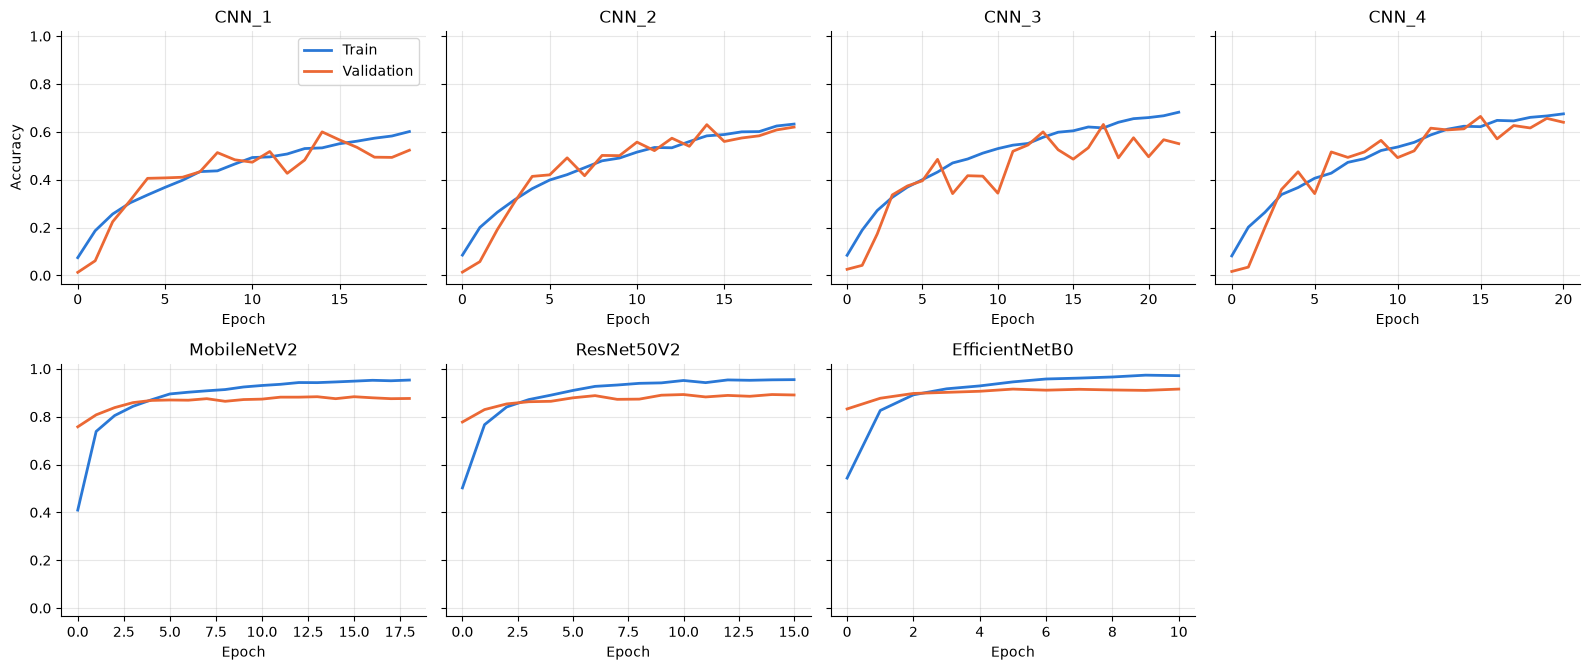

In [7]:
n = len(info)
cols = 4
fig, axes = plt.subplots(int(np.ceil(n / cols)), cols, figsize=(16, 3.4 * np.ceil(n / cols)), sharey=True)
for ax, name in zip(axes.flat, info['Model']):
    h = json.load(open(f'results/history_{name}.json'))
    ax.plot(h['accuracy'], color=TRAIN_C, label='Train')
    ax.plot(h['val_accuracy'], color=VAL_C, label='Validation')
    ax.set_title(name); ax.set_xlabel('Epoch')
for ax in axes.flat[n:]:
    ax.axis('off')
axes.flat[0].set_ylabel('Accuracy'); axes.flat[0].legend()
plt.tight_layout()
plt.show()

## 4.7 Accuracy Comparison

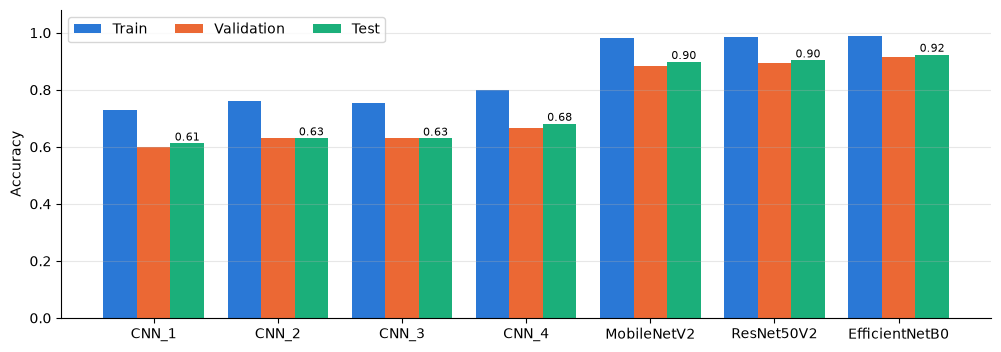

In [8]:
x = np.arange(len(res))
w = 0.27
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w, res['Train Acc'], w, color=TRAIN_C, label='Train')
ax.bar(x, res['Val Acc'], w, color=VAL_C, label='Validation')
ax.bar(x + w, res['Test Acc'], w, color=TEST_C, label='Test')
for xi, v in zip(x, res['Test Acc']):
    ax.text(xi + w, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x, res['Model'])
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.08)
ax.legend(loc='upper left', ncols=3)
ax.grid(axis='x', visible=False)
plt.show()

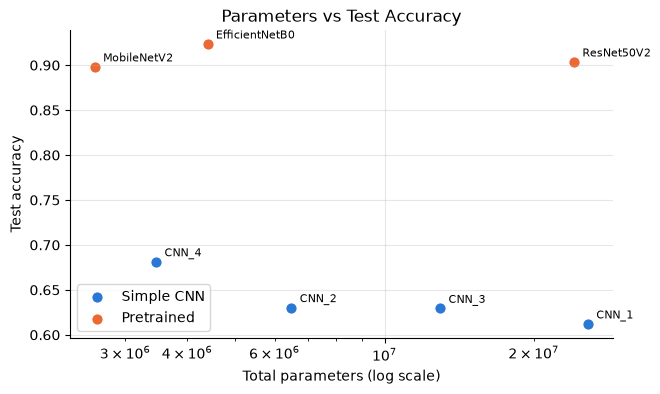

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for t, c in [('Simple CNN', TRAIN_C), ('Pretrained', VAL_C)]:
    d = res[res['Type'] == t]
    ax.scatter(d['Params'], d['Test Acc'], s=70, color=c, label=t, edgecolor='white')
    for _, r in d.iterrows():
        ax.annotate(r['Model'], (r['Params'], r['Test Acc']), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Total parameters (log scale)'); ax.set_ylabel('Test accuracy')
ax.set_title('Parameters vs Test Accuracy')
ax.legend()
plt.show()

## 4.8 Best Model Summary

In [10]:
best = keras.models.load_model(f'models/{best_name}.keras')
r = res[res['Model'] == best_name].iloc[0]
print(f"Model        : {best_name} ({r['Type']})")
print(f"Architecture : {r['Architecture']}")
print(f"Params       : {r['Params']:,}")
print(f"Train / Val / Test accuracy : {r['Train Acc']:.4f} / {r['Val Acc']:.4f} / {r['Test Acc']:.4f}")
best.summary()

Model        : EfficientNetB0 (Pretrained)
Architecture : EfficientNetB0 (frozen) + Dense 256
Params       : 4,396,268
Train / Val / Test accuracy : 0.9871 / 0.9152 / 0.9235


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 73)             │        18,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,089,664 (19.42 MB)

 Trainable params: 346,697 (1.32 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 693,396 (2.65 MB)

## 4.9 Comparison and Analysis

In [12]:
summary = res.groupby('Type', sort=False).agg(
    Models=('Model', 'count'),
    Best_Test_Acc=('Test Acc', 'max'),
    Mean_Test_Acc=('Test Acc', 'mean'),
    Mean_Gap=('Gap (Train-Test)', 'mean'),
    Mean_Params=('Params', 'mean'),
    Mean_Train_Time_s=('Train Time (s)', 'mean'),
).round(4)
summary['Mean_Params'] = summary['Mean_Params'].astype(int)
summary

,Models,Best_Test_Acc,Mean_Test_Acc,Mean_Gap,Mean_Params,Mean_Train_Time_s
Type,,,,,,
Simple CNN,4,0.6812,0.6382,0.1235,12155577,1951.75
Pretrained,3,0.9235,0.9083,0.0762,10369684,821.00


### Simple CNNs (test accuracy 61–68%)

| Model | Params | Test Acc | Observation |
|---|---|---|---|
| CNN_1 [32, 64] | 25.7M | 61.2% | Only 2 poolings leave a 56x56x64 map, so the Dense layer is huge. Most params, lowest accuracy. |
| CNN_2 [32, 64, 64] | 6.5M | 63.0% | A third block + pooling cuts params by 75% and improves accuracy. |
| CNN_3 [32, 64, 128] | 12.9M | 62.9% | Doubling the last block's filters doubles params with no gain over CNN_2. |
| CNN_4 [32, 64, 128, 128] | 3.5M | **68.1%** | Deepest and smallest model, and the best simple CNN. |

- **Depth + pooling matters more than parameter count:** from CNN_1 to CNN_4, params fall by 87% (25.7M → 3.5M) and test accuracy rises by 6.9 points.
- **Validation curves are noisy** (e.g. CNN_3 val accuracy 63% → 49% in one epoch). Early stopping with restored best weights kept the best epoch.
- **Not fully converged:** training accuracy was still rising when early stopping fired (epochs 20–23). More epochs, higher patience or a learning-rate schedule could improve these models.
- During training, train accuracy was *below* validation accuracy (e.g. CNN_4: 62% vs 66%), because augmentation and dropout are only active in training.

### Pretrained Models (test accuracy 90–92%)

| Model | Total / Trainable Params | Test Acc | Train Time | Best Epoch |
|---|---|---|---|---|
| MobileNetV2 | 2.6M / 0.35M | 89.8% | 553 s | 14 |
| ResNet50V2 | 24.1M / 0.54M | 90.4% | 1430 s | 11 |
| EfficientNetB0 | 4.4M / 0.35M | **92.4%** | **480 s** | **6** |

- All three reach ~76–83% validation accuracy after **one epoch**, because ImageNet features already describe shapes, textures and colours well.
- **EfficientNetB0 beats ResNet50V2 with 5.5x fewer parameters and 3x less training time**, so larger is not always better.
- MobileNetV2 is the smallest model and is only 2.5 points behind the best.

### Simple CNN vs Pretrained
- **Accuracy:** the best pretrained model is **+24.2 points** above the best simple CNN (92.4% vs 68.1% test).
- **Overfitting:** the mean Train−Test gap is about 12 points for simple CNNs vs about 8 points for pretrained models. Frozen ImageNet features generalise better than features learned from ~5k images.
- **Cost:** pretrained models train only a small head (0.35–0.54M trainable params), so they trained faster (480–1430 s) than the simple CNNs (1390–2584 s), even though their total size is similar or larger.
- **Conclusion:** with ~70 training images per class, a CNN trained from scratch does not have enough data to learn strong features. Transfer learning solves this.

## 4.10 Final Model Selection and Justification

**Selected model: EfficientNetB0 (frozen ImageNet base + Dense 256 head)**

| Metric | Value |
|---|---|
| Validation accuracy (selection criterion) | **91.5%** (highest) |
| Test accuracy | **92.4%** (highest) |
| Train accuracy | 98.7% |
| Train−Test gap | 6.4 points (smallest) |
| Total / trainable params | 4.4M / 0.35M |
| Training time | 480 s, best at epoch 6 (fastest) |

**Justification**
1. **Highest validation accuracy**, which was the selection rule. Its test accuracy is also the highest, which confirms the choice on unseen data.
2. **Generalises best:** the smallest Train−Test gap of all 7 models.
3. **Efficient:** 5.5x fewer params than ResNet50V2, the fastest to train, and a small model file (~21 MB).
4. **Stable training:** validation accuracy was smooth and plateaued early, unlike the noisy simple-CNN curves.

**Alternatives**
- **MobileNetV2:** for very limited hardware (fewest params, 89.8% test).
- **CNN_4:** the best model trained from scratch (68.1% test). It is the baseline that shows the value of transfer learning.

**Possible improvements:** fine-tune the top layers of EfficientNetB0 with a low learning rate; for the simple CNNs, train longer with a learning-rate schedule.